# Indici di concentrazione

In presenza di variabili che rappresentano beni condivisibili in una
popolazione, come per esempio la ricchezza, ci si può chiedere quanto la
variabile sia equamente distribuita tra gli individui della popolazione, oppure
quanto sia concentrata solo su un numero ridotto di osservazioni. Questo
concetto è diverso dalla varianza, che misura la dispersione dei valori intorno
a un valore medio.

Date $n$ osservazioni, indichiamo con $a_1, \dots, a_n$ il loro elenco una
volta che queste sono state ordinate. Successivamente calcoliamone il valore
medio

$$
\bar a = \frac{1}{n} \sum_{i=1}^n a_i
$$

e sommiamole, ottenendo $\mathrm{TOT} = n \bar a = \sum_{i=1}^n a_i$. Possiamo
avere due situazioni estreme:

1. in caso di concentrazione minima tutti gli elementi del campione assumono lo
   stesso valore: $a_1 = a_2 = \dots = a_n = \bar a$;
2. in caso di concentrazione massima tutti gli elementi del campione assumono
   il valore $0$, a parte uno:  $a_1 = a_2 = \dots = a_{n-1} = 0$ e
   $a_n = n \bar a$.

In generale allora ci può interessare valutare un indice di concentrazione, che
valga $0$ oppure $1$ nei casi rispettivamente di concentrazione minima e
massima, e che sia negli altri casi sia un valore crescente in funzione della
concentrazione. Consideriamo:

- la frequenza relativa cumulata fino all'$i$-esima osservazione:
  $F_i = \frac{i}{n}$, per $i = 1, \dots, n$, e
- la quantità relativa cumulata fino all'$i$-esima osservazione:
  $Q_i = \frac{\sum_{k=1}^i a_k}{\mathrm{TOT}}$.

Si verifica facilmente che

- $0 \leq F_i \leq 1$ e $0 \leq Q_i \leq 1$;
- $Q_i \leq F_i$ dal momento che le osservazioni sono state ordinate in modo
  crescente;
- $Q_i = F_i$ nel caso di concentrazione minima;
- $Q_n = F_n$.

Per $i = 1, \dots,n$ le coppie $(F_i, Q_i)$ indicano che il $100 F_i \%$ della
popolazione detiene il $100 Q_i \%$ della quantità considerata. Se si
considerano i punti sul piano che sono identificati da queste coppie:

- nel caso di concentrazione minima tutti i punti $(F_i, Q_i)$ giacciono sulla
retta $F = Q$: possiamo dunque dire che in questo caso $F_i - Q_i = 0$ per ogni
$i$;

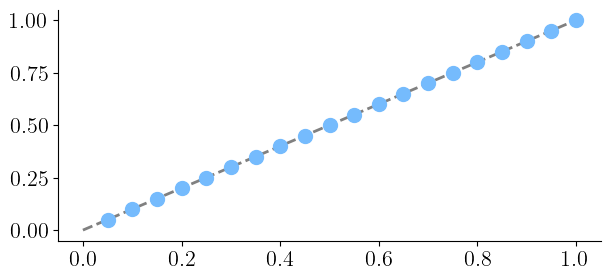

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('sds.mplstyle')

heroes = pd.read_csv('data/heroes.csv', sep=';', index_col=0)

tot = 10
n = 20
a = [tot/n] * n
q = np.cumsum(a) / tot
f = np.arange(1, n+1) / n
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=2, c='gray')
plt.plot(f, q, 'o')
plt.show()

- nel caso di concentrazione massima i punti $(F_i, Q_i)$ per
  $i = 1, \dots, n-1$ giacciono sulla retta $Q = 0$, tranne l'ultimo per cui
  $F_n = Q_n = 1$: dunque in questo caso $F_i - Q_i = F_i$ per
  $i = 1, \dots, n-1$ e $F_n - Q_n = 0$.

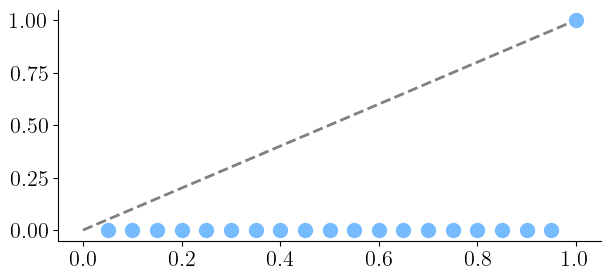

In [2]:
tot = 10
n = 20
a = [0] * (n-1) + [tot]
q = np.cumsum(a) / tot
f = np.arange(1, n+1) / n
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=2, c='gray')
plt.plot(f, q, 'o')
plt.show()

Nei casi intermedi si avrà dunque che i punti staranno su una curva "sotto" la
retta $F = Q$, dato che $Q_i \leq F_i$, e più tale curva si "allontana" dalla
retta, più la concentrazione è alta.

L'area compresa tra la curva dei punti $(F_i, Q_i)$ (detta _curva di Lorentz_)
e la retta di equidistribuzione (la retta a $45^{\circ}$) è detta
_area di concentrazione_ e può essere utilizzata come base per la definizione
di appositi rapporti di concentrazione, di cui l'indice di Gini costituisce un
esempio. Maggiore infatti è la concentrazione osservata, maggiore sarà tale
area.

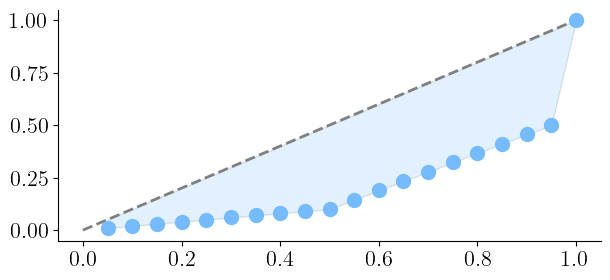

In [3]:
tot = 10
n = 20
a = [tot/100]*10 + [tot*4/90]*9 + [tot/2]
q = np.cumsum(a) / tot
f = np.arange(1, n+1) / n
plt.fill_between(f, f, q, alpha=0.2)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=2, c='gray')
plt.plot(f, q, 'o')
plt.show()

Verifichiamo quale sia la concentrazione dell'attributo _Strength_, nell'idea
di verificare se la forza sia più o meno equamente distribuita tra i supereroi.

In [4]:
strength = heroes[pd.notnull(heroes['Strength'])]['Strength']

Le quantità relative cumulate si ottengono ordinando i valori, calcolando le
corrispondenti somme cumulate e dividendole per la "quantità" totale di forza.

In [5]:
Q = strength.sort_values().cumsum() / sum(strength)

Le frequenze relative cumulate sono facili da calcolare: il loro vettore ha
come componenti i valori che vanno da $\frac{1}{n}$ a $1$, incrementandoli ogni
volta di $\frac{1}{n}$, dove $n$ indica il numero di valori osservati.

In [6]:
import numpy as np
n = len(strength)
F = np.arange(1, n+1) / n

Pertanto il grafico che mostra l'area di concentrazione è il seguente, in cui a
causa dell'elevato numero di osservazioni è più opportuno visualizzare le
quantità relative cumulate (i valori di $Q$) usando una spezzata piuttosto che
un insieme di punti.

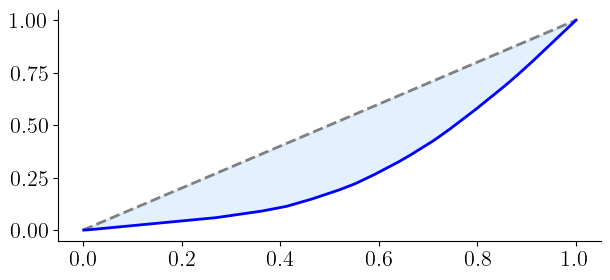

In [7]:
plt.fill_between(F, F, Q, alpha=0.2)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=2, c='gray')
plt.plot(F, Q, linewidth=2, c='blue')
plt.show()

Il risultato evidenzia una distribuzione della forza relativamente vicina alla
situazione di concentrazione minima.

I diagrammi come quello appena ottenuto devono essere analizzati
_qualitativamente_, mentre spesso è più comodo avere un indice numerico
calcolato a partire dai dati, il cui valore possa facilmente essere confrontato
con due estremi minimo e massino. In tal senso si definisce
_indice di concentrazione (o coefficiente) di Gini_ il rapporto

$$
	G = \frac{\sum_{i=1}^{n-1}F_i - Q_i}{\sum_{i=1}^{n-1}F_i}
$$

tra la quantità $\sum_{i=1}^{n-1}F_i - Q_i$ e il suo valore massimo

$$
\sum_{i=1}^{n-1}F_i = \frac{1}{n} \sum_{i=1}^{n-1} i =
                      \frac{1}{n} \frac{(n-1)n}{2} = \frac{(n-1)}{2}
$$

Per quanto appena visto,

- $0 \leq G \leq 1$, e
- $G = \frac{2}{n-1} \sum_{i=1}^{n-1} F_i - Q_i$

Siamo ora in grado di calcolare indice di concentrazione di Gini per
l'attributo _Strength_: sottraendo componente per componente il vettore delle
quantità cumulate a quello delle frequenze cumulate, sommando i risultati e
moltiplicando per $\frac{2}{n-1}$ si ottiene il valore dell'indice di
concentrazione.

In [8]:
2 * sum(F - Q) / (n-1)

0.4118214635457669

In accordo con il grafico precedentemente generato, $G$ assume un valore
intermedio tra i due possibili estremi, a indicare una distribuzione della
forza debolmente concentrata su un sottoinsieme dei supereroi.